In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<b><font size="6" color="red">ch.08 Transformer 영화평 구분하기</font></b>
- lmdb사이트의 5만개 영화 감상평 : Train/test - 타겟변수 : 부정/긍정

# 1. 패키지 import

In [2]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from time import time # unix time을 계산하기 위해

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense

from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

# 2. 하이퍼 파라미터 설정
- 하이퍼파라미터를 바꾸면 모델의 정확도나 속도에 차이남

In [3]:
MY_WORDS = 13000 # imdb 데이터 안의 단어 수
MY_LENGTH = 220   # 독립변수 차원(영화평 평균길이 정도가 좋음)
MY_EMBED = 32    # Embedding 결과 차원
MY_HIDDEN = 62   # LSTM의 unit의 수

MY_EPOCH = 30    # fit 반복학습수
MY_BATCH = 200   # 배치사이즈(fit할 때, 매번 가져오는 데이터 수)

# 불용어 설정(빈도수가 높은 상위 1~50은 대부분 the, a, is....)
SKIP_TOP = 30

# 3. 데이터 불러오기

In [5]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=MY_WORDS, #1~MY_WORDS 이외는 2로 가져옴
                                                     )

In [125]:
print('학습용 독립변수 모양', X_train.shape)
print('학습용 타겟변수 모양', y_train.shape)
print('학습용 독립변수 샘플', X_train[0][:80])
print('학습용 타겟변수(0:부정/1:긍정)', y_train[0])
print('테스트용 독립변수 모양 :', X_test.shape)
print('테스트용 타겟변수 모양 :', y_test.shape)

학습용 독립변수 모양 (25000,)
학습용 타겟변수 모양 (25000,)
학습용 독립변수 샘플 [2, 2, 2, 2, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 2, 173, 36, 256, 2, 2, 100, 43, 838, 112, 50, 670, 2, 2, 35, 480, 284, 2, 150, 2, 172, 112, 167, 2, 336, 385, 39, 2, 172, 4536, 1111, 2, 546, 38, 2, 447, 2, 192, 50, 2, 2, 147, 2025, 2, 2, 2, 2, 1920, 4613, 469, 2, 2, 71, 87, 2, 2, 43, 530, 38, 76, 2, 2, 1247, 2, 2, 2]
학습용 타겟변수(0:부정/1:긍정) 1
테스트용 독립변수 모양 : (25000,)
테스트용 타겟변수 모양 : (25000,)


In [109]:
# 부/긍정 갯수
print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())

1    12500
0    12500
dtype: int64
0    12500
1    12500
dtype: int64


In [110]:
# 긍정 갯수
print('학습데이터의 긍정 갯수 :', y_train.sum())
print('테스트 데이터의 긍정 개수 :', y_test.sum())

학습데이터의 긍정 갯수 : 12500
테스트 데이터의 긍정 개수 : 12500


# 4. 문자단어 -> 정수

In [6]:
word_to_id = imdb.get_word_index() # 단어(word): 정수(id) (빈도가 높은 단어는 앞으로)
print(word_to_id['movie'])
print(word_to_id['film'])
print(word_to_id['the'])
# 정수 -> 문자 단어
id_to_word = {} # 정수(id) : 문자단어
for key, value in word_to_id.items():
    id_to_word[value] = key
print(id_to_word[17])
print(id_to_word.get(19))
print(id_to_word.get(1))
# SKIP_TOP값을 고민하기 위해 최빈 단어(현재 SKIP_TOP값 20)
print([id_to_word[idx] for idx in range(1,37)])

17
19
1
movie
film
the
['the', 'and', 'a', 'of', 'to', 'is', 'br', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with', 'movie', 'but', 'film', 'on', 'not', 'you', 'are', 'his', 'have', 'he', 'be', 'one', 'all', 'at', 'by', 'an', 'they', 'who', 'so', 'from']


In [112]:
msg = "What a wonderful moviesdsad"
msg = msg.lower().split()
print(msg)
# 1: 리뷰의 시작을 알리는 숫자 2: MY_WORDS(10000)이내에 들어가지 않는 단어, 3:padding 처리
data = [1] + [word_to_id.get(m, -1) + 3 for m in msg]
print('원 후기 내용 :', msg)
print('인코딩 된 내용(data) :', data)
print('data 추정 :', ' '.join([id_to_word.get(d-3, '???') for d in data]))

['what', 'a', 'wonderful', 'moviesdsad']
원 후기 내용 : ['what', 'a', 'wonderful', 'moviesdsad']
인코딩 된 내용(data) : [1, 51, 6, 389, 2]
SKIP_TOP처리할 경우 : [2, 51, 2, 389, 2]
data 추정 : ??? what ??? wonderful ???


In [105]:
[id_to_word.get(d-3, '???') for d in data]

['???', 'what', '???', 'wonderful', '???']

# 5. 숫자 영화평 -> 자연어 영화평 함수

In [127]:
def decoding(review_nums):
    decoded = [] # 숫자를 단어로 해석한 내용 append
    #print(review_nums)
    for num in review_nums:
        word = id_to_word.get(num-3, '???')
        decoded.append(word)
    print(' '.join(decoded))

In [128]:
print(X_train[0])
decoding(X_train[0])

[2, 2, 2, 2, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 2, 173, 36, 256, 2, 2, 100, 43, 838, 112, 50, 670, 2, 2, 35, 480, 284, 2, 150, 2, 172, 112, 167, 2, 336, 385, 39, 2, 172, 4536, 1111, 2, 546, 38, 2, 447, 2, 192, 50, 2, 2, 147, 2025, 2, 2, 2, 2, 1920, 4613, 469, 2, 2, 71, 87, 2, 2, 43, 530, 38, 76, 2, 2, 1247, 2, 2, 2, 515, 2, 2, 2, 626, 2, 2, 2, 62, 386, 2, 2, 316, 2, 106, 2, 2, 2223, 5244, 2, 480, 66, 3785, 33, 2, 130, 2, 2, 38, 619, 2, 2, 124, 51, 36, 135, 48, 2, 1415, 33, 2, 2, 2, 215, 2, 77, 52, 2, 2, 407, 2, 82, 2, 2, 2, 107, 117, 5952, 2, 256, 2, 2, 2, 3766, 2, 723, 36, 71, 43, 530, 476, 2, 400, 317, 46, 2, 2, 2, 1029, 2, 104, 88, 2, 381, 2, 297, 98, 32, 2071, 56, 2, 141, 2, 194, 7486, 2, 2, 226, 2, 2, 134, 476, 2, 480, 2, 144, 30, 5535, 2, 51, 36, 2, 224, 92, 2, 104, 2, 226, 65, 2, 38, 1334, 88, 2, 2, 283, 2, 2, 4472, 113, 103, 32, 2, 2, 5345, 2, 178, 32]
??? ??? ??? ??? just brilliant casting location scenery story direction everyone's really suited ??? part they 

# 6. 영화평 학습용 데이터 처음 10개의 길이 출력 함수

In [54]:
def show_length():
    print('첫 20개 영화평 길이')
    # for i in range(11):
    #     print(f'{i}번째 길이 :{len(X_train[0])}')
    print([len(x) for x in X_train[:21]])
show_length()

첫 20개 영화평 길이
[218, 189, 141, 550, 147, 43, 123, 562, 233, 130, 450, 99, 117, 238, 109, 129, 163, 752, 212, 177, 129]


In [55]:
print('pad_sequence 작업 전')
show_length()

pad_sequence 작업 전
첫 20개 영화평 길이
[218, 189, 141, 550, 147, 43, 123, 562, 233, 130, 450, 99, 117, 238, 109, 129, 163, 752, 212, 177, 129]


In [57]:
# X_train 후기 중 가장 긴 단어수, 가장 짧은 단어 수
max([len(x) for  x in X_train]), min([len(x) for  x in X_train])

(2494, 11)

In [35]:
# 영화평 길이 평균
np.mean([len(x) for x in X_train])

238.71364

# 7. 모든 영화평의 길이를 동일하게(MY_LENGTH만큼)
- post자르기, post붙이기: 75.5%
- post자르기, pre붙이기: 75.3%
- pre자르기, post붙이기: 75.9%
- pre자르기, pre붙이기:  75.7%

In [7]:
X_train = pad_sequences(X_train,
                        maxlen=MY_LENGTH,
                        # truncating='post', # 80단어(maxlen) 이상일 경우 어디를 자를지 여부
                        truncating ='pre',
                        padding='post',
                        # padding='pre', 
                       ) # 길경우, 뒷부분을 자르고 짧은 경우 뒤에 0을 붙임
X_test = pad_sequences(X_test,
                        maxlen=MY_LENGTH,
                        # truncating='post', # 80단어(maxlen) 이상일 경우 어디를 자를지 여부
                        truncating ='pre',
                        padding='post',
                        # padding='pre', 
                       )

# 8. 최종 데이터 shape 확인

In [9]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 220), (25000,), (25000, 220), (25000,))

# 9.1 LSTM 모델 생성 구현

In [148]:
model = Sequential()
model.add(Embedding(input_dim=MY_WORDS, # 10000
                    output_dim=MY_EMBED, # 32
                    input_length=MY_LENGTH
                   ))
model.add(LSTM(units=MY_HIDDEN,
               dropout=0.5, # 0.1~0.5 각 step 마다 LSTM 셀로 틀어가는 값의 30%를 0으로
               recurrent_dropout= 0.3, # 0.1 ~ 0.3 이전 LSTM에서 다음 LSTM샐로 가는 연결 20%를 0으로
               input_shape=(MY_LENGTH, MY_EMBED),
               # kernel_initializer='he_normal', # 입력 가중치 초기화
               # recurrent_initializer='orthogonal' # 순환 가중치 초기화
              ))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 230, 32)           320000    
                                                                 
 lstm_2 (LSTM)               (None, 62)                23560     
                                                                 
 dense_2 (Dense)             (None, 1)                 63        
                                                                 
Total params: 343,623
Trainable params: 343,623
Non-trainable params: 0
_________________________________________________________________


# 9.2 Transformer 인코딩부분 모델 구현

In [13]:
from tensorflow import range
from tensorflow.keras.layers import Input, Dropout, MultiHeadAttention, add
from tensorflow.keras.layers import BatchNormalization, GlobalAvgPool1D, Dense
from tensorflow.keras.models import Model, Sequential

# 입력층, 임베딩층
INPUTS = Input(shape=(MY_LENGTH,))
INPUTS_EMBEDDING = Embedding(input_dim=MY_WORDS,
                            output_dim=MY_EMBED)(INPUTS)
# Positional Encoding
POSITIONS = range(start=0,
                 limit=MY_LENGTH)
POS_ENCODING = Embedding(input_dim = MY_WORDS,
                        output_dim = MY_EMBED)(POSITIONS)
POS_ENC_OUTPUT = POS_ENCODING + INPUTS_EMBEDDING

# Multti_Head_Attention
ATTENTION_OUTPUT = MultiHeadAttention(num_heads=3, key_dim=MY_EMBED)(POS_ENC_OUTPUT, POS_ENC_OUTPUT)
X = add([POS_ENC_OUTPUT, ATTENTION_OUTPUT])
X = BatchNormalization()(X)

# FFN(Feed Foward Network)
FFN=Sequential([
    Dense(MY_HIDDEN, activation='relu'),
    Dense(MY_EMBED, activation='relu')
])(X)
X = add([FFN, X])
X = BatchNormalization()(X)

# 하나의 벡터로 하여 Dense에 보냄
X = GlobalAvgPool1D()(X)
X = Dropout(0.1)(X)

X = Dense(units= MY_HIDDEN, activation='relu')(X)
X = Dropout(0.1)(X)
OUTPUTS = Dense(units=2, # 부정 그룹/긍정 그룹(다중분류분석)
               activation='softmax')(X)

model = Model(inputs = INPUTS,
             outputs = OUTPUTS)

# 10. 학습환경 설정 및 학습하기

In [14]:
model.compile(#loss='binary_crossentropy', # 이중분류 (로지스틱 회귀분석)
              loss = 'sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['acc']
             )
earlyStopping = EarlyStopping(monitor='val_loss', patience=3)
start = time() # 70.1.1 ~ 이 시점까지의 초 수
hist = model.fit(X_train, y_train,
                 epochs = MY_EPOCH,
                 batch_size=MY_BATCH,
                 validation_split=0.2,
                 callbacks=[earlyStopping],
                 verbose=1)
end = time()
print('총 fit시간 : {:.5f}'.format(end-start))

Epoch 1/30
100/100 [==============================] - 45s 442ms/step - loss: 0.4535 - acc: 0.7826 - val_loss: 0.5536 - val_acc: 0.8136
Epoch 2/30
100/100 [==============================] - 46s 465ms/step - loss: 0.2050 - acc: 0.9214 - val_loss: 0.4569 - val_acc: 0.8580
Epoch 3/30
100/100 [==============================] - 47s 466ms/step - loss: 0.1428 - acc: 0.9470 - val_loss: 0.3627 - val_acc: 0.8624
Epoch 4/30
100/100 [==============================] - 46s 463ms/step - loss: 0.0995 - acc: 0.9654 - val_loss: 0.3300 - val_acc: 0.8602
Epoch 5/30
100/100 [==============================] - 47s 466ms/step - loss: 0.0762 - acc: 0.9732 - val_loss: 0.4657 - val_acc: 0.8220
Epoch 6/30
100/100 [==============================] - 47s 468ms/step - loss: 0.0588 - acc: 0.9780 - val_loss: 0.6110 - val_acc: 0.8382
Epoch 7/30
100/100 [==============================] - 46s 465ms/step - loss: 0.0539 - acc: 0.9808 - val_loss: 0.6624 - val_acc: 0.8436
총 fit시간 : 324.01132


# 11. 모델 평가

In [67]:
hist.history.keys()

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])

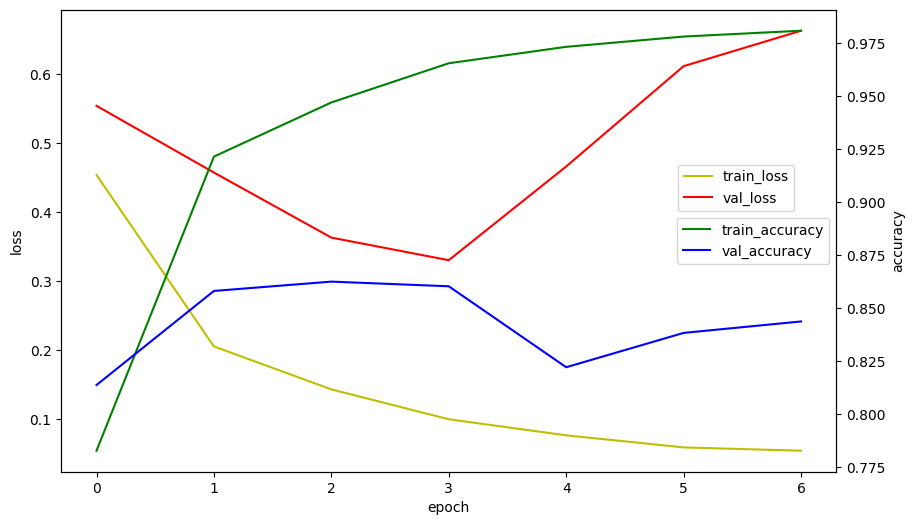

In [15]:
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['acc'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_acc'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [151]:
# 테스트 데이터로 평가
loss, acc = model.evaluate(X_test,y_test)
print('test 데이터의 정확도 :', acc)

782/782 [==============================] - 14s 17ms/step - loss: 0.3817 - acc: 0.8600
test 데이터의 정확도 : 0.860040009021759


In [152]:
# 모델 저장
model.save('imdb_v2.10_skip20length80.h5')

In [153]:
# 혼동행렬(교차표, 평가성능지표)
# y_test 실제값
pred = model.predict(X_test)
y_hat = (pred>=0.5).astype(int) # 예측값
y_hat

782/782 [==============================] - 13s 17ms/step


array([[0],
       [1],
       [1],
       ...,
       [0],
       [0],
       [1]])

In [54]:
y_test.shape, y_hat.shape

((25000,), (25000, 1))

In [55]:
# 실제값(1차원)과 예측값(2차원)의 차원이 같지 않아도 됨
confusion_matrix(y_test,y_hat)

array([[ 9114,  3386],
       [ 2265, 10235]], dtype=int64)

In [60]:
# 실제값(1차원)과 예측값(2차원)의 차원이 1차원이여야 실행 가능
ctab = pd.crosstab(y_test, y_hat.reshape(-1), rownames=['실제값'], colnames=['예측값'])
ctab['0확률'] = ctab[0]/(ctab[0]+ctab[1])*100
ctab['1확률'] = ctab[1]/(ctab[0]+ctab[1])*100
ctab

예측값,0,1,0확률,1확률
실제값,,,,
0,9114,3386,72.912,27.088
1,2265,10235,18.120,81.880


In [64]:
# accuracy, precision recall, f1_score
print('acc :', acc)
print('precision :', precision_score(y_test, y_hat))
print('recall :', recall_score(y_test, y_hat))
print('f1 score :', f1_score(y_test, y_hat))

acc : 0.7739599943161011
precision : 0.7514132589384039
recall : 0.8188
f1 score : 0.7836606561770223


# 12. 모델 사용하기

In [154]:
import re
review = '''This film was truly the best cinematic experience. 
The storyline flowed seamlessly, and the characters’ emotions were portrayed with such depth that it drew the audience in completely. 
The visuals and soundtrack blended perfectly, amplifying the emotional impact. 
The ending delivered an unexpected twist along with a heartfelt message that lingers long after watching. 
It was so satisfying that I felt the urge to watch it again. The movie offered every joy and inspiration cinema can provide.'''.lower()
review = re.sub('[^a-zA-Z0-9\s]', ' ', review)
review = review.split()
print(review)
encoded = [1]+ [word_to_id.get(r,-1) + 3 for r in review]
encoded = [2 if (e <= 30)|(e>10000) else e for e in encoded] # skip_top 사용 시
print(encoded)

['this', 'film', 'was', 'truly', 'the', 'best', 'cinematic', 'experience', 'the', 'storyline', 'flowed', 'seamlessly', 'and', 'the', 'characters', 'emotions', 'were', 'portrayed', 'with', 'such', 'depth', 'that', 'it', 'drew', 'the', 'audience', 'in', 'completely', 'the', 'visuals', 'and', 'soundtrack', 'blended', 'perfectly', 'amplifying', 'the', 'emotional', 'impact', 'the', 'ending', 'delivered', 'an', 'unexpected', 'twist', 'along', 'with', 'a', 'heartfelt', 'message', 'that', 'lingers', 'long', 'after', 'watching', 'it', 'was', 'so', 'satisfying', 'that', 'i', 'felt', 'the', 'urge', 'to', 'watch', 'it', 'again', 'the', 'movie', 'offered', 'every', 'joy', 'and', 'inspiration', 'cinema', 'can', 'provide']
[2, 2, 2, 2, 371, 2, 118, 1360, 585, 2, 769, 2, 2, 2, 2, 105, 1438, 71, 1000, 2, 141, 1137, 2, 2, 2266, 2, 311, 2, 340, 2, 2057, 2, 816, 2, 950, 2, 2, 921, 1488, 2, 277, 2132, 35, 2076, 1009, 367, 2, 2, 5348, 749, 2, 2, 196, 103, 149, 2, 2, 38, 2349, 2, 2, 421, 2, 4238, 2, 106, 2, 

In [155]:
input_data = pad_sequences([encoded],
                        maxlen=MY_LENGTH,
                        truncating='post', # 80단어(maxlen) 이상일 경우 어디를 자를지 여부
                        # truncating ='pre',
                        # padding='post',
                        padding='pre', 
                       ) # 길경우, 뒷부분을 자르고 짧은 경우 뒤에 0을 붙임
print(input_data, len(encoded))

[[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    2    2
     2    2  371    2  118 1360  585    2  769    2    2    2    2  105
  1438   71 1000    2  141 1137    2    2 2266    2  311    2  340    2
  2057    2  816    2  950    2    2  921 1488    2  277 2132   

In [156]:
model.predict(input_data)

1/1 [==============================] - 0s 45ms/step


array([[0.9855981]], dtype=float32)

In [157]:
review = '''This movie was the worst experience. The plot was messy, and the characters’ actions lacked credibility, making it hard to stay engaged. 
The visuals and soundtrack felt mismatched, distracting rather than enhancing the story. 
The ending was hollow, failing to deliver any meaningful message or emotional impact. It left no lasting impression, only frustration. 
Watching it felt like a waste of time and expectations. 
There was no joy, inspiration, or satisfaction—just disappointment from start to finish.'''.lower()
review = re.sub('[^a-zA-Z0-9\s]', ' ', review)
review = review.split()
print(review)
encoded = [1]+ [word_to_id.get(r,-1) + 3 for r in review]
encoded = [2 if (e <= 30)|(e>10000) else e for e in encoded] # skip_top 사용 시
print(encoded)

['this', 'movie', 'was', 'the', 'worst', 'experience', 'the', 'plot', 'was', 'messy', 'and', 'the', 'characters', 'actions', 'lacked', 'credibility', 'making', 'it', 'hard', 'to', 'stay', 'engaged', 'the', 'visuals', 'and', 'soundtrack', 'felt', 'mismatched', 'distracting', 'rather', 'than', 'enhancing', 'the', 'story', 'the', 'ending', 'was', 'hollow', 'failing', 'to', 'deliver', 'any', 'meaningful', 'message', 'or', 'emotional', 'impact', 'it', 'left', 'no', 'lasting', 'impression', 'only', 'frustration', 'watching', 'it', 'felt', 'like', 'a', 'waste', 'of', 'time', 'and', 'expectations', 'there', 'was', 'no', 'joy', 'inspiration', 'or', 'satisfaction', 'just', 'disappointment', 'from', 'start', 'to', 'finish']
[2, 2, 2, 2, 2, 249, 585, 2, 114, 2, 5922, 2, 2, 105, 1729, 3674, 3059, 231, 2, 254, 2, 789, 3953, 2, 2057, 2, 816, 421, 2, 4075, 247, 74, 2, 2, 65, 2, 277, 2, 4086, 3718, 2, 1645, 101, 3191, 749, 42, 921, 1488, 2, 317, 57, 5863, 1384, 64, 4185, 149, 2, 421, 40, 2, 437, 2, 58,

In [158]:
input_data = pad_sequences([encoded],
                        maxlen=MY_LENGTH,
                        truncating='post', # 80단어(maxlen) 이상일 경우 어디를 자를지 여부
                        # truncating ='pre',
                        # padding='post',
                        padding='pre', 
                       ) # 길경우, 뒷부분을 자르고 짧은 경우 뒤에 0을 붙임
print(input_data, len(encoded))

[[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    2    2
     2    2    2  249  585    2  114    2 5922    2    2  105 1729 3674
  3059  231    2  254    2  789 3953    2 2057    2  816  421    2 4075
   247   74    2    2   65    2  277    2 4086 3718    2 1645  1

In [159]:
model.predict(input_data)

1/1 [==============================] - 0s 43ms/step


array([[0.01258289]], dtype=float32)